- ## **Import Libraries:**


In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

- ## **Load Dataset churn_cleaned.csv**

In [111]:
df = pd.read_csv("../data/preprocessed/churn_cleaned.csv")

In [112]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (7043, 15)

Columns:
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']

Missing values:
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
dtype: int64


## **Feature Engineering:**

In [113]:
df["Avg Monthly Spend"] = (
    df["Total Charges"] /
    df["Tenure Months"].replace(0, 1)
)

In [114]:
print(df[
    ["Tenure Months", "Total Charges", "Avg Monthly Spend"]
].head())

   Tenure Months  Total Charges  Avg Monthly Spend
0              2         108.15          54.075000
1              2         151.65          75.825000
2              8         820.50         102.562500
3             28        3046.05         108.787500
4             49        5036.30         102.781633


Seperate Features in x and y:

In [115]:
X = df.drop("Churn Label",axis=1)
Y = df["Churn Label"]

In [116]:
print("Shape of x: ",X.shape)
print("Shape of y: ",Y.shape)

print("\n X columns: ",X.columns.tolist())
print("\n Y Target values: ",Y.value_counts())

Shape of x:  (7043, 15)
Shape of y:  (7043,)

 X columns:  ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Avg Monthly Spend']

 Y Target values:  Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


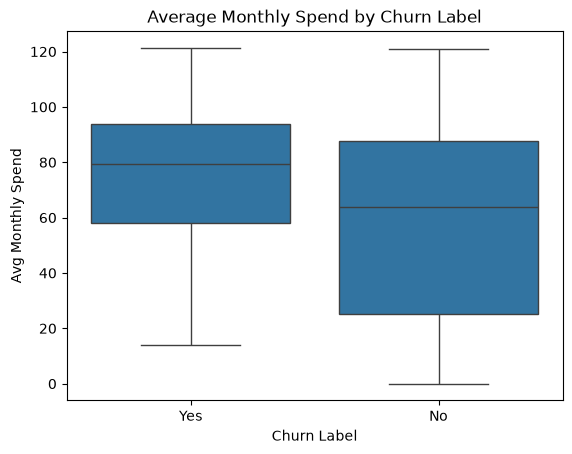

In [133]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Avg Monthly Spend"
)

plt.title("Average Monthly Spend by Churn Label")
plt.show()

- correlation:

In [143]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)
corr_matrix = numeric_df.corr(method="spearman")

print(corr_matrix)

                   Tenure Months  Monthly Charges  Total Charges  \
Tenure Months           1.000000         0.276417       0.889696   
Monthly Charges         0.276417         1.000000       0.638028   
Total Charges           0.889696         0.638028       1.000000   
Avg Monthly Spend       0.276405         0.990696       0.638850   

                   Avg Monthly Spend  
Tenure Months               0.276405  
Monthly Charges             0.990696  
Total Charges               0.638850  
Avg Monthly Spend           1.000000  


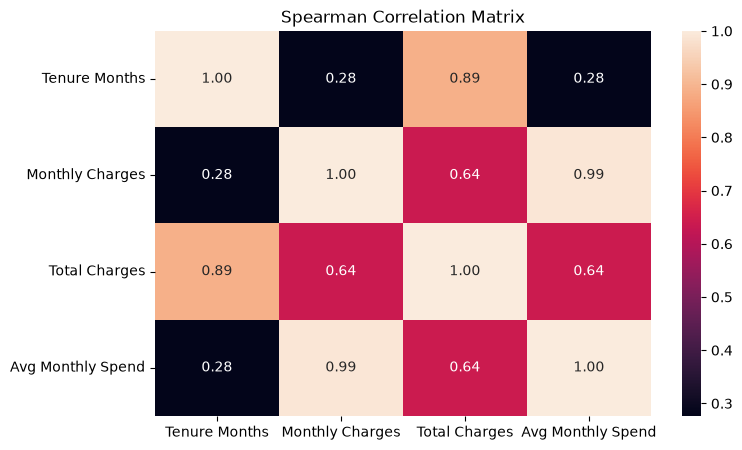

In [146]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix")
plt.show()

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)

In [118]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test :", Y_test.shape)

X_train: (5634, 15)
X_test : (1409, 15)
y_train: (5634,)
y_test : (1409,)


In [119]:
print("\nTraining distribution:")
print(Y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(Y_test.value_counts(normalize=True) * 100)


Training distribution:
Churn Label
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Testing distribution:
Churn Label
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


In [120]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

## **Data Preprcessing**

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [122]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num','passthrough',numeric_features),
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)
    ]
)

- **RandomForestClassifier:**

In [123]:
from sklearn.ensemble import RandomForestClassifier

In [124]:
rf_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(
        random_state=42)
    )
])

In [125]:
rf_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Senior Citizen','Partner','Dependents',...,'Monthly Charges', 'Total Charges','Avg Monthly Spend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [126]:
y_pred_rf = rf_pipeline.predict(X_test)

In [127]:
print(y_pred_rf[:20])

['No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'No' 'No' 'No' 'No' 'No' 'No']


In [128]:
print("Number of predictions:", len(y_pred_rf))

Number of predictions: 1409


In [129]:
print(Y_test.head(20).values)

<StringArray>
[ 'No',  'No',  'No',  'No',  'No',  'No',  'No',  'No',  'No', 'Yes',  'No',
  'No',  'No', 'Yes',  'No',  'No',  'No',  'No',  'No',  'No']
Length: 20, dtype: str


## **Model Evaluation:**

- Let's check it's confusion matrics first:


In [130]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
cm_rf = confusion_matrix(Y_test, y_pred_rf)

print(cm_rf)

[[917 118]
 [182 192]]


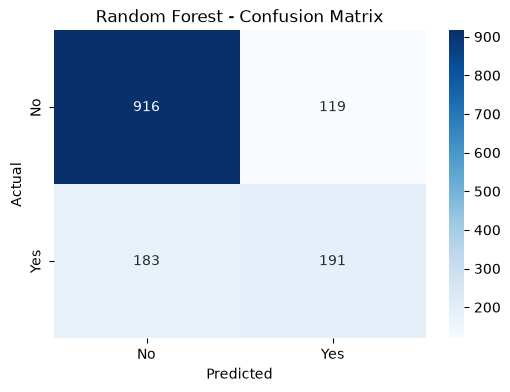

In [108]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

- TN: 916
- TP: 191
- FN: 183
- FP: 119

In [131]:
print("Accuracy: ",
      accuracy_score(Y_test, y_pred_rf))

print("Precision:",
      precision_score(Y_test, y_pred_rf, pos_label="Yes"))

print("Recall:   ",
      recall_score(Y_test, y_pred_rf, pos_label="Yes"))

print("F1-Score: ",
      f1_score(Y_test, y_pred_rf, pos_label="Yes"))

print("ROC-AUC:  ",
      roc_auc_score(
          (Y_test == "Yes").astype(int),
          rf_pipeline.predict_proba(X_test)[:, 1]
      ))

Accuracy:  0.78708303761533
Precision: 0.6193548387096774
Recall:    0.5133689839572193
F1-Score:  0.5614035087719298
ROC-AUC:   0.8332325815701774


- XGBoost Classifier:

In [136]:
from xgboost import XGBClassifier

In [140]:
X = df.drop("Churn Label", axis=1)

Y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [141]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [142]:
print(Y_train.value_counts())
print(Y_test.value_counts())

Churn Label
0    4139
1    1495
Name: count, dtype: int64
Churn Label
0    1035
1     374
Name: count, dtype: int64


In [137]:

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [138]:

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['No' 'Yes']